In [ ]:
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [ ]:
import os

# Define the path to the dataset directory
dataset_path = "/content/drive/MyDrive/Dataset BUSI with GT"

# Get the list of image files
image_files = []
labels = []

# Iterate over the directories
for class_name in ['benign', 'malignant', 'normal']:
    class_path = os.path.join(dataset_path, class_name)
    for filename in os.listdir(class_path):
        image_path = os.path.join(class_path, filename)
        image_files.append(image_path)
        labels.append(class_name)

# Convert labels to numerical values
from tensorflow.keras.utils import to_categorical

# Convert labels to numerical values
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)
# Get the original class labels from the label encoder
original_labels = label_encoder.classes_

# Convert labels to one-hot encoded format
labels = to_categorical(labels)


# Print the mapping between numerical values and original labels
for numerical_value, original_label in enumerate(original_labels):
    print(f"Numerical Value: {numerical_value}, Original Label: {original_label}")


Numerical Value: 0, Original Label: benign
Numerical Value: 1, Original Label: malignant
Numerical Value: 2, Original Label: normal


### **CNN**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(image_files, labels, test_size=0.2, random_state=42, stratify=labels)

In [ ]:
# Define a function to load and preprocess the images
def load_preprocess_image(image_path):
    image = Image.open(image_path)
    image = image.resize((150, 150))
#this converts the image to BW
    image = image.convert('L')
    image = np.array(image)
    image = image.reshape((150, 150, 1))
#image normalization
    image = image.astype('float32') / 255.0
    return image

X_train = [str(image_path) for image_path in X_train]
X_test = [str(image_path) for image_path in X_test]

# Load and preprocess the training images and labels
X_train = [load_preprocess_image(image_path) for image_path in X_train]
X_train = np.array(X_train)
y_train= np.array(y_train)

# Load and preprocess the testing images and labels
X_test= [load_preprocess_image(image_path) for image_path in X_test]
X_test = np.array(X_test)
y_test = np.array(y_test)

(1104, 150, 150, 1) (1104, 3)
(474, 150, 150, 1) (474, 3)


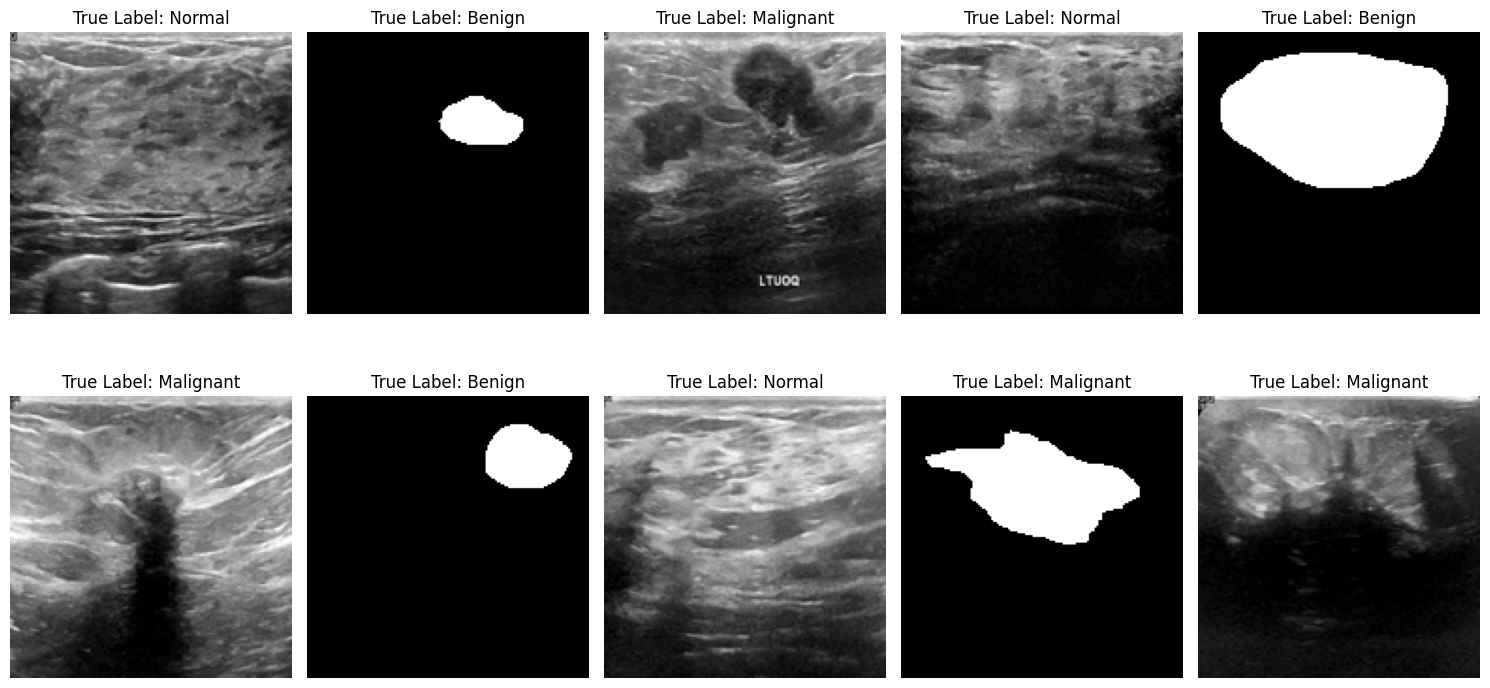

In [ ]:
#Check size and color channels of images and labels
print(X_train.shape, y_train.shape)
print(X_test.shape,y_test.shape)

#Show images
images = X_test[:10]  # Assuming X_test contains the image data
labels = y_test[:10]  # Assuming y_test contains the corresponding labels

# Convert them to class indices
class_indices = np.argmax(labels, axis=1)

# Define class labels
class_labels = ['Benign', 'Malignant', 'Normal']

num_rows = 2
num_cols = len(images) // num_rows

# Create a grid of subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 8))

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Display images with labels in the subplots
for i in range(len(images)):
    ax = axes[i]
    ax.imshow(images[i], cmap='gray')  # Assuming images are 2D arrays (grayscale)
    ax.set_title(f'True Label: {class_labels[class_indices[i]]}')
    ax.axis('off')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3, MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Concatenate, Flatten, Dense, Dropout, Conv2D

# Input shape for both models
input_shape = (150, 150, 1)  # Single-channel input

# Define input layer
input_layer = Input(shape=input_shape)

# Convert single-channel input to three channels
expanded_input = Conv2D(3, (1, 1), padding='same')(input_layer)

# InceptionV3 branch
inception_base = InceptionV3(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
inception_branch = inception_base(expanded_input)
inception_flatten = Flatten()(inception_branch)

# MobileNetV2 branch
mobilenet_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
mobilenet_branch = mobilenet_base(expanded_input)
mobilenet_flatten = Flatten()(mobilenet_branch)

# Concatenate the outputs from both branches
merged = Concatenate()([inception_flatten, mobilenet_flatten])

# Additional custom layers for classification
dense_layer = Dense(128, activation='relu')(merged)
dropout_layer = Dropout(0.5)(dense_layer)
output_layer = Dense(3, activation='softmax')(dropout_layer)  # 3 classes (benign, malignant, normal)

# Create the model
model = Model(inputs=input_layer, outputs=output_layer)

# Freeze the pre-trained layers
for layer in inception_base.layers + mobilenet_base.layers:
    layer.trainable = False

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


Epoch 1/200
35/35 [==============================] - 20s 294ms/step - loss: 2.4669 - accuracy: 0.6703 - val_loss: 0.5527 - val_accuracy: 0.7405
Epoch 2/200
35/35 [==============================] - 6s 169ms/step - loss: 0.5746 - accuracy: 0.7627 - val_loss: 0.5274 - val_accuracy: 0.7468
Epoch 3/200
35/35 [==============================] - 5s 153ms/step - loss: 0.5378 - accuracy: 0.7717 - val_loss: 0.4821 - val_accuracy: 0.7785
Epoch 4/200
35/35 [==============================] - 6s 171ms/step - loss: 0.4548 - accuracy: 0.7853 - val_loss: 0.4393 - val_accuracy: 0.7911
Epoch 5/200
35/35 [==============================] - 6s 167ms/step - loss: 0.4139 - accuracy: 0.8080 - val_loss: 0.4123 - val_accuracy: 0.8059
Epoch 6/200
35/35 [==============================] - 6s 170ms/step - loss: 0.4147 - accuracy: 0.7998 - val_loss: 0.4938 - val_accuracy: 0.7637
Epoch 7/200
35/35 [==============================] - 5s 149ms/step - loss: 0.3774 - accuracy: 0.8361 - val_loss: 0.3982 - val_accuracy: 0.820

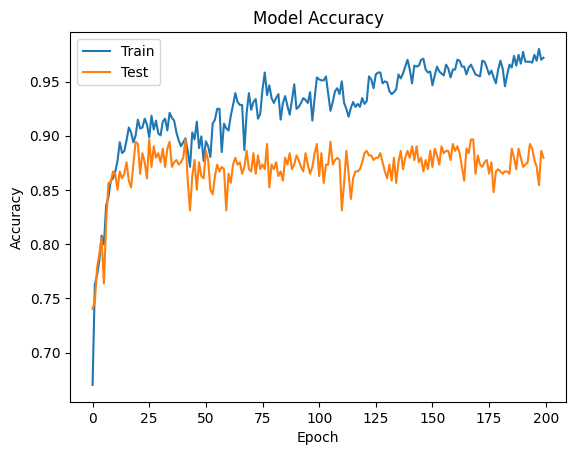

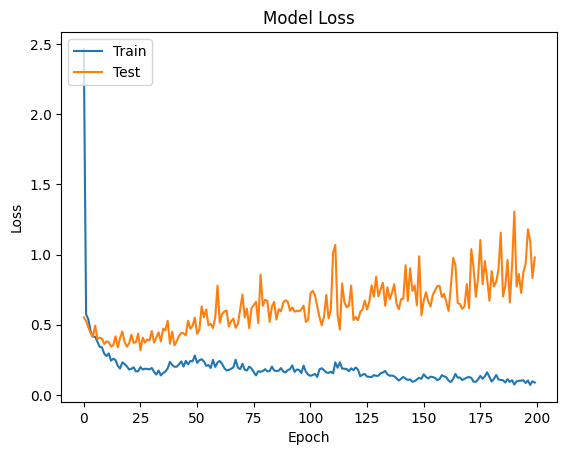

In [ ]:
# Train the model and collect the history
history = model.fit(X_train, y_train, epochs=200, batch_size=32, validation_data=(X_test, y_test))


# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()


In [ ]:
model.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_14 (InputLayer)       [(None, 150, 150, 1)]        0         []                            
                                                                                                  
 conv2d_571 (Conv2D)         (None, 150, 150, 3)          6         ['input_14[0][0]']            
                                                                                                  
 inception_v3 (Functional)   (None, 3, 3, 2048)           2180278   ['conv2d_571[0][0]']          
                                                          4                                       
                                                                                                  
 mobilenetv2_1.00_224 (Func  (None, 5, 5, 1280)           2257984   ['conv2d_571[0][0]']    

1/1 [==============================] - 0s 28ms/step


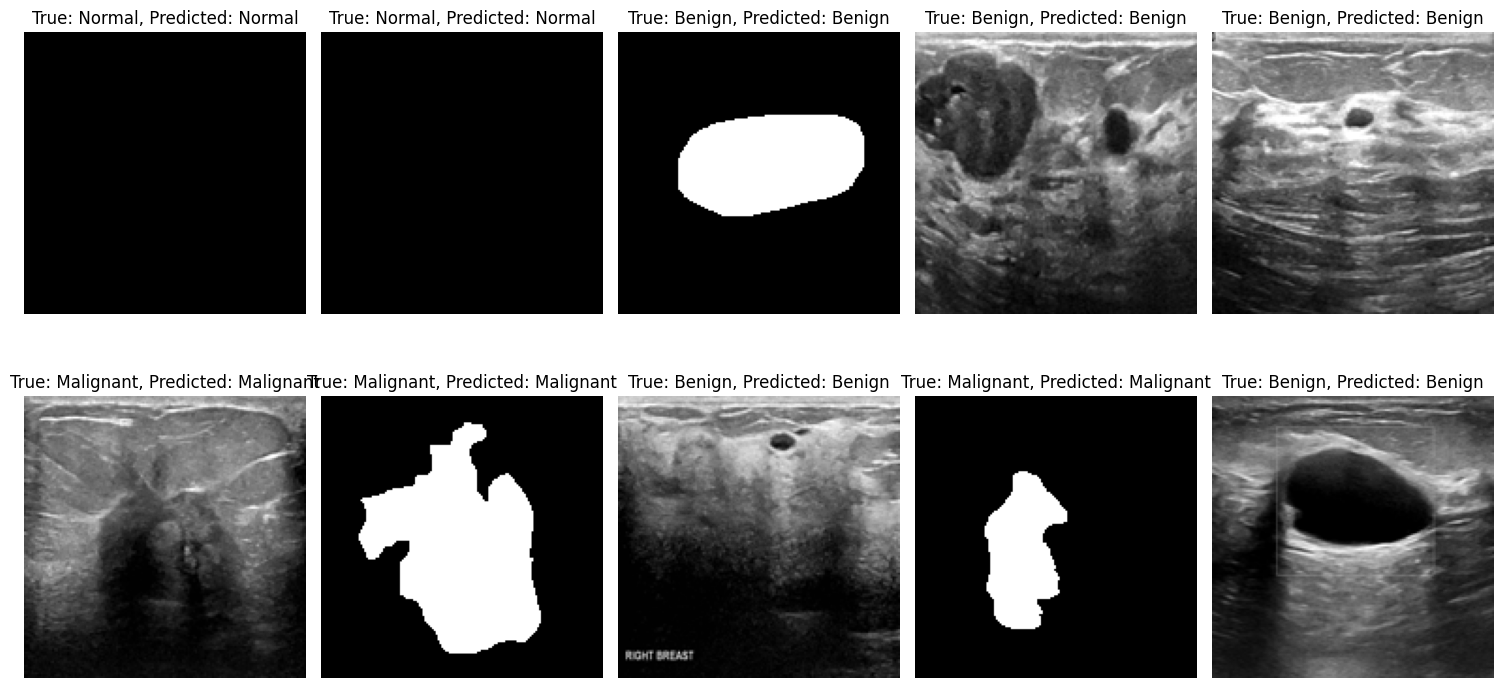

<Figure size 640x480 with 0 Axes>

In [ ]:
num_images_to_display = 10
selected_indices = np.random.choice(len(X_test), num_images_to_display, replace=False)
class_names = ['Benign', 'Malignant', 'Normal']
# Create a subplot grid
num_rows = 2
num_cols = num_images_to_display // num_rows
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 8))

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Display predictions for the selected test images
for i, index in enumerate(selected_indices):
    # Get the test image and true label
    test_image = X_test[index]
    true_label = np.argmax(y_test[index])

    # Preprocess the image
    img_array = np.expand_dims(test_image, axis=0)

    # Make predictions
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions)

    # Display the image
    ax = axes[i]
    ax.imshow(test_image.reshape((150, 150)), cmap='gray')
    ax.set_title(f'True: {class_names[true_label]}, Predicted: {class_names[predicted_class]}')
    ax.axis('off')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()
plt.savefig('/content/drive/MyDrive/Dataset BUSI with GT/prediction.png')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model


# Save the trained model
model.save('/content/drive/MyDrive/Dataset BUSI with GT/modelHybrid1.h5')



/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


15/15 [==============================] - 3s 50ms/step


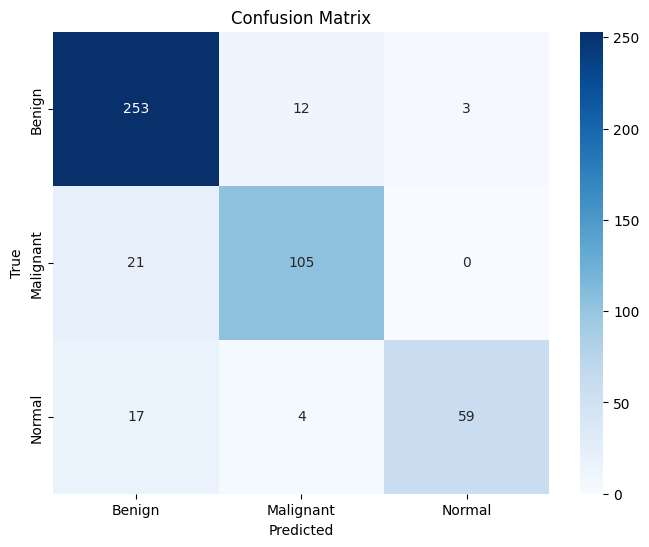

Classification Report:
               precision    recall  f1-score   support

      Benign       0.87      0.94      0.91       268
   Malignant       0.87      0.83      0.85       126
      Normal       0.95      0.74      0.83        80

    accuracy                           0.88       474
   macro avg       0.90      0.84      0.86       474
weighted avg       0.88      0.88      0.88       474



In [ ]:
# Load the model
loaded_model = load_model('/content/drive/MyDrive/Dataset BUSI with GT/modelHybrid1.h5')

# Evaluate the model on the test set
y_pred = loaded_model.predict(X_test)

# Convert one-hot encoded labels back to class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Plot confusion matrix with seaborn
conf_mat = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant', 'Normal'], yticklabels=['Benign', 'Malignant', 'Normal'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Plot classification report
class_report = classification_report(y_true_classes, y_pred_classes, target_names=['Benign', 'Malignant', 'Normal'])
print('Classification Report:\n', class_report)


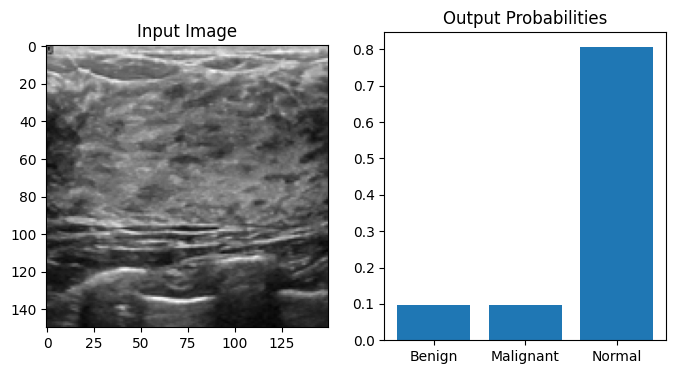

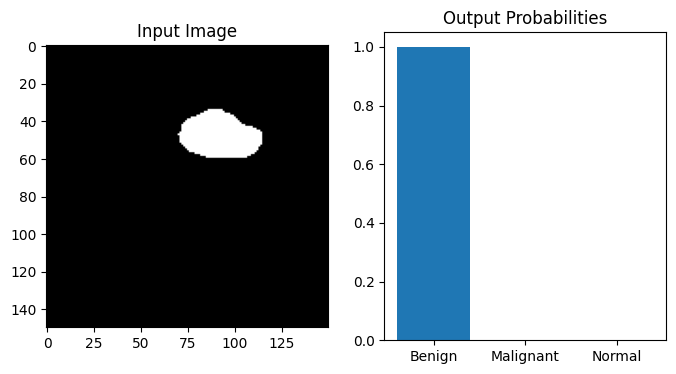

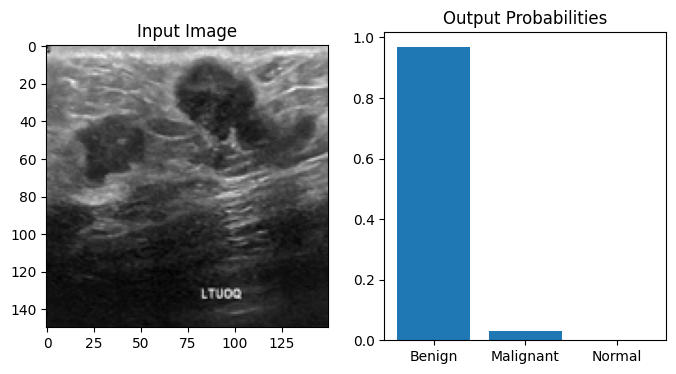

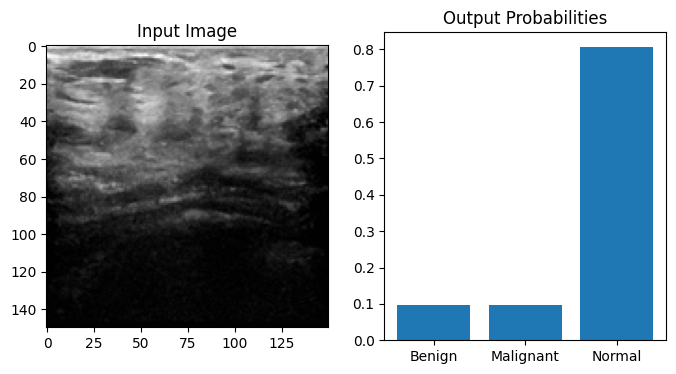

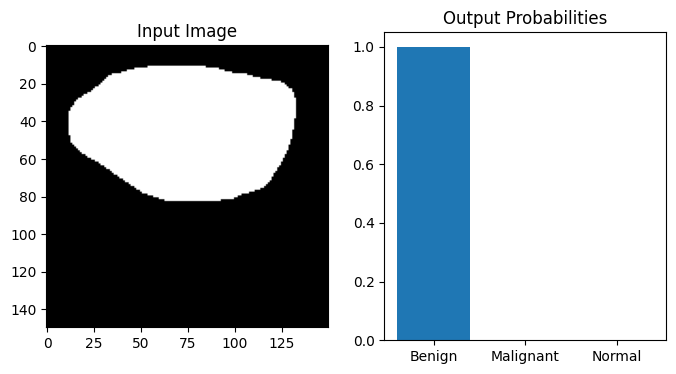

In [ ]:
# Visualize input-to-output
for i in range(5):  # You can adjust the range based on the number of samples you want to visualize
    input_image = X_test[i].reshape((150, 150))  # Assuming your input shape is (150, 150, 1)
    output_probabilities = y_pred[i]
    predicted_class = np.argmax(output_probabilities)

    plt.figure(figsize=(8, 4))

    # Plot input image
    plt.subplot(1, 2, 1)
    plt.imshow(input_image, cmap='gray')
    plt.title('Input Image')

    # Plot output probabilities
    plt.subplot(1, 2, 2)
    plt.bar(range(len(output_probabilities)), output_probabilities)
    plt.xticks(range(len(output_probabilities)), ['Benign', 'Malignant', 'Normal'])
    plt.title('Output Probabilities')

    plt.show()